In [1]:
import sys
sys.path.append("..")

In [253]:
from omegaconf import OmegaConf
from itertools import combinations
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import os
import re

In [3]:
from sentence_transformers import SentenceTransformer, util
from datasets import load_dataset

/Users/c/Library/Caches/pypoetry/virtualenvs/pesto-R9MfnoAy-py3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from presto import Presto

In [226]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

In [165]:
config = OmegaConf.load("../config.yml")

In [7]:
models = {m: SentenceTransformer(*m.split()) for m in config.models}
datasets = {d: load_dataset(*d.split()) for d in config.datasets}

/Users/c/Library/Caches/pypoetry/virtualenvs/pesto-R9MfnoAy-py3.10/lib/python3.10/site-packages/datasets/load.py:1429: FutureWarning: The repository for big_patent contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/big_patent
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


In [367]:
with open("../data/combined_results.pkl", "rb") as f:
    results = pickle.load(f)

In [368]:
metric = Presto(max_homology_dim=config.max_homology_dim, n_components=config.n_components, normalize=config.normalize)

In [369]:
avg_landscapes = dict()
finegrained = dict()
scores = dict()
finegrained_scores = dict()
for dataset, v1 in results.items():
    for model, v2 in v1.items():
        for n_samples, v3 in v2.items():
            avg_landscapes[(dataset, model, n_samples)] = metric.average_landscape(v3["landscapes"])
            for n_projections in config.n_projections:
                finegrained[(dataset, model, n_samples, n_projections)] = metric.average_landscape({i:v3["landscapes"][i][:n_projections] for i in range(config.max_homology_dim + 1)})
for (k1,v1), (k2,v2) in list(combinations(avg_landscapes.items(),2)) + [((k1,v1),(k1,v1)) for k1, v1 in avg_landscapes.items()]:
    scores[(k1,k2)] = metric.compute_presto_scores(v1, v2)
for (k1,v1), (k2,v2) in list(combinations(finegrained.items(),2)) + [((k1,v1),(k1,v1)) for k1, v1 in finegrained.items()]:
    finegrained_scores[(k1,k2)] = metric.compute_presto_scores(v1, v2)

In [479]:
def create_score_df(scores):
    df = pd.DataFrame(scores).T.sort_values(0, ascending=False).reset_index().rename(
        {"level_0":"m1", "level_1":"m2", 0:"dim0", 1:"dim1", 2:"dim2"}, axis=1)
    df["m1_dataset"] = df.m1.map(lambda x:x[0])
    df["m2_dataset"] = df.m2.map(lambda x:x[0])
    df["datasets"] = df.m1_dataset + "/" + df.m2_dataset
    df["m1_model"] = df.m1.map(lambda x:x[1])
    df["m2_model"] = df.m2.map(lambda x:x[1])
    df["models"] = df.m1_model + "/" + df.m2_model
    df["m1_n_samples"] = df.m1.map(lambda x:x[2])
    df["m2_n_samples"] = df.m2.map(lambda x:x[2])
    df["sample_diff"] = [abs(x-y) for x,y in zip(df.m1_n_samples, df.m2_n_samples)]
    if df.m1.map(len)[0] == 4:
        df["m1_n_projections"] = df.m1.map(lambda x:x[3])
        df["m2_n_projections"] = df.m2.map(lambda x:x[3])
        df["projection_diff"] = [abs(x-y) for x,y in zip(df.m1_n_projections, df.m2_n_projections)]
    df["aggregate_presto"] = df.dim0 + df.dim1 + df.dim2
    df["average_presto"] = df["aggregate_presto"] / 3
    return df

In [480]:
df_coarse = create_score_df(scores)
df_coarse.head(2)

,m1,m2,dim0,dim1,dim2,m1_dataset,m2_dataset,datasets,m1_model,m2_model,models,m1_n_samples,m2_n_samples,sample_diff,aggregate_presto,average_presto
0,"(big_patent a, all-mpnet-base-v2, 16384)","(cnn_dailymail 3.0.0, all-mpnet-base-v2, 1024)",0.277219,0.073253,0.018486,big_patent a,cnn_dailymail 3.0.0,big_patent a/cnn_dailymail 3.0.0,all-mpnet-base-v2,all-mpnet-base-v2,all-mpnet-base-v2/all-mpnet-base-v2,16384,1024,15360,0.368957,0.122986
1,"(big_patent a, all-mpnet-base-v2, 16384)","(cnn_dailymail 3.0.0, all-MiniLM-L6-v2, 1024)",0.273128,0.074939,0.019954,big_patent a,cnn_dailymail 3.0.0,big_patent a/cnn_dailymail 3.0.0,all-mpnet-base-v2,all-MiniLM-L6-v2,all-mpnet-base-v2/all-MiniLM-L6-v2,16384,1024,15360,0.368021,0.122674


In [481]:
df_fine = create_score_df(finegrained_scores)
df_fine.head(2)

,m1,m2,dim0,dim1,dim2,m1_dataset,m2_dataset,datasets,m1_model,m2_model,models,m1_n_samples,m2_n_samples,sample_diff,m1_n_projections,m2_n_projections,projection_diff,aggregate_presto,average_presto
0,"(big_patent a, all-MiniLM-L6-v2, 2048, 4)","(gfissore/arxiv-abstracts-2021, all-MiniLM-L6-...",0.628949,0.079895,0.026682,big_patent a,gfissore/arxiv-abstracts-2021,big_patent a/gfissore/arxiv-abstracts-2021,all-MiniLM-L6-v2,all-MiniLM-L6-v2,all-MiniLM-L6-v2/all-MiniLM-L6-v2,2048,1024,1024,4,4,0,0.735526,0.245175
1,"(big_patent a, all-MiniLM-L6-v2, 2048, 4)","(gfissore/arxiv-abstracts-2021, all-distilrobe...",0.626053,0.094683,0.029755,big_patent a,gfissore/arxiv-abstracts-2021,big_patent a/gfissore/arxiv-abstracts-2021,all-MiniLM-L6-v2,all-distilroberta-v1,all-MiniLM-L6-v2/all-distilroberta-v1,2048,16384,14336,4,4,0,0.750491,0.250164


In [482]:
df_fine.to_csv("finegrained_score_data.csv.gz")

### Same model, same dataset – looking at effect of sample size and number of projections

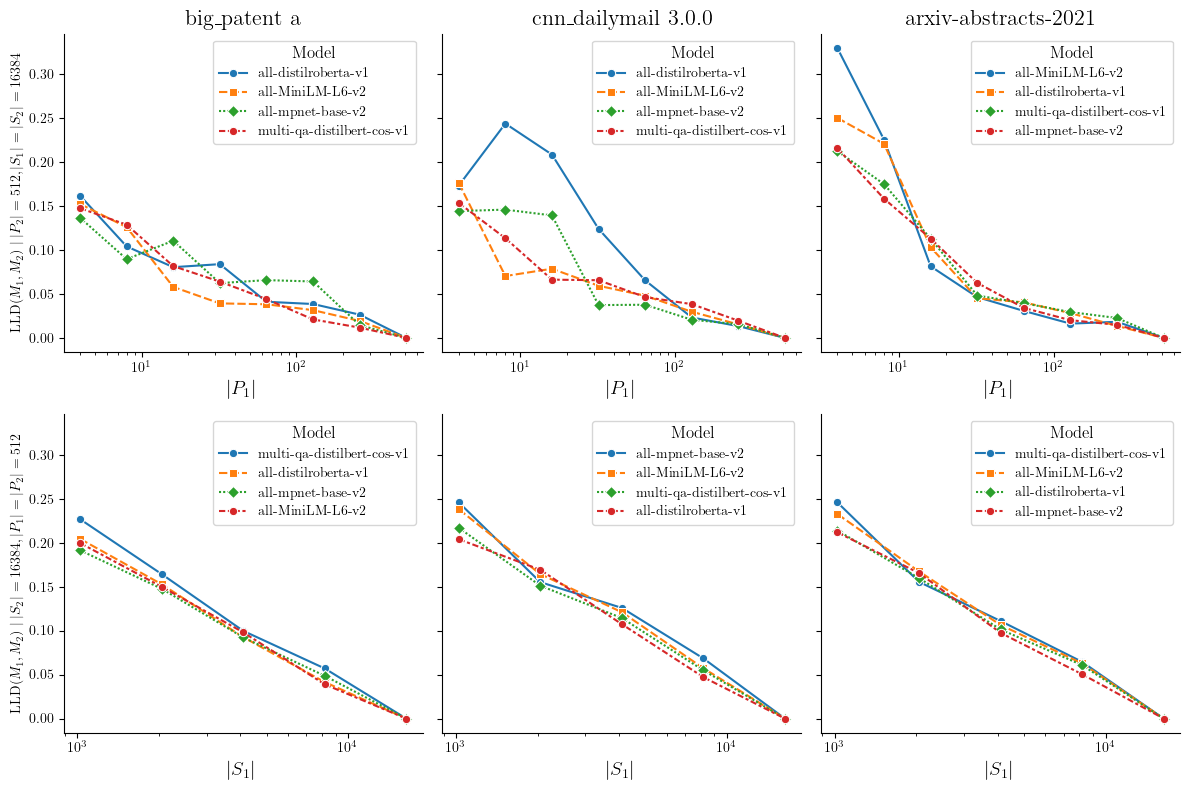

In [373]:
samples_m2 = 16384
projections_m2 = 512
label_fontsize = 14
legend_fontsize = 12
df = df_fine.query("m1_model == m2_model and m1_dataset == m2_dataset and m2_n_samples == @samples_m2 and m2_n_projections == @projections_m2")
fig, ax = plt.subplots(2,3,figsize=(12,8), sharey=True, sharex=False)
for idx,dataset in enumerate(sorted(datasets)):
    sns.lineplot(data=df.query("m1_dataset == @dataset and m1_n_samples == m2_n_samples"), 
                 x="m1_n_projections", 
                 y="aggregate_presto", 
                 hue="m1_model",
                 style="m1_model",
                 ax=ax[0][idx],
                 markers="osD"
                )
    ax[0][idx].set_title(dataset.split("/")[-1], fontsize=label_fontsize + 2)
    ax[0][idx].set_ylabel(rf"LLD$(M_1,M_2) \mid |P_2| = {projections_m2}, |S_1| = |S_2| = {samples_m2}$")
    ax[0][idx].set_xlabel(rf"$|P_1|$", fontsize=label_fontsize)
    ax[0][idx].set_xscale("log")
    ax[0][idx].legend(title="Model", title_fontsize=legend_fontsize)
    sns.lineplot(data=df.query("m1_dataset == @dataset and m1_n_projections == m2_n_projections"), 
                 x="m1_n_samples", 
                 y="aggregate_presto", 
                 hue="m1_model",
                 style="m1_model",
                 ax=ax[1][idx],
                 markers="osD"
                )
    ax[1][idx].set_ylabel(rf"LLD$(M_1,M_2) \mid |S_2| = {samples_m2}, |P_1| = |P_2| = {projections_m2}$", ha="center")
    ax[1][idx].set_xlabel(rf"$|S_1|$", fontsize=label_fontsize)
    ax[1][idx].set_xscale("log")
    ax[1][idx].legend(title="Model", title_fontsize=legend_fontsize)
sns.despine(fig)
plt.tight_layout()
plt.savefig("effects_sample-size_n-projections.pdf", bbox_inches="tight", transparent=True)

### Different model, same dataset, same sample size, same number of projections

In [374]:
samples_m2 = 16384
projections_m2 = 512
label_fontsize = 14
legend_fontsize = 12
df = df_fine.query("m1_dataset == m2_dataset and m1_n_samples == m2_n_samples == @samples_m2 and m1_n_projections == m2_n_projections == @projections_m2")

In [375]:
pdfs = dict()
for dataset in df.m1_dataset.unique():
    pdf = df.query("m1_dataset == @dataset").pivot(index=["m1_model"], columns=["m2_model"], values="aggregate_presto"
                                                  ).sort_index(key=lambda v:v.map(lambda x:x.lower()), ascending=False)
    pdf = pdf[sorted(pdf.columns, key=lambda x:x.lower())]
    pdfs[dataset] = pdf.loc[[*pdf.index[1:], pdf.index[0]]][[pdf.columns[-1],*pdf.columns[:-1]]].fillna(0)
    pdfs[dataset] += pdfs[dataset].T

In [376]:
pdfs['big_patent a']

m2_model,multi-qa-distilbert-cos-v1,all-distilroberta-v1,all-MiniLM-L6-v2,all-mpnet-base-v2
m1_model,,,,
all-mpnet-base-v2,0.053564,0.058974,0.060694,0.000000
all-MiniLM-L6-v2,0.025173,0.026415,0.000000,0.060694
all-distilroberta-v1,0.030970,0.000000,0.026415,0.058974
multi-qa-distilbert-cos-v1,0.000000,0.030970,0.025173,0.053564


In [377]:
pdfs['cnn_dailymail 3.0.0']

m2_model,multi-qa-distilbert-cos-v1,all-distilroberta-v1,all-MiniLM-L6-v2,all-mpnet-base-v2
m1_model,,,,
all-mpnet-base-v2,0.036474,0.027670,0.019356,0.000000
all-MiniLM-L6-v2,0.035488,0.025863,0.000000,0.019356
all-distilroberta-v1,0.029084,0.000000,0.025863,0.027670
multi-qa-distilbert-cos-v1,0.000000,0.029084,0.035488,0.036474


In [378]:
pdfs['gfissore/arxiv-abstracts-2021']

m2_model,multi-qa-distilbert-cos-v1,all-distilroberta-v1,all-MiniLM-L6-v2,all-mpnet-base-v2
m1_model,,,,
all-mpnet-base-v2,0.066249,0.042959,0.045887,0.000000
all-MiniLM-L6-v2,0.037700,0.014965,0.000000,0.045887
all-distilroberta-v1,0.038679,0.000000,0.014965,0.042959
multi-qa-distilbert-cos-v1,0.000000,0.038679,0.037700,0.066249


In [379]:
melted_df = df_fine.query("m1_n_samples == m2_n_samples == @samples_m2 and m1_n_projections == m2_n_projections == @projections_m2"
             ).melt(id_vars=["m1_dataset", "m2_dataset", "m1_model", "m2_model"], value_vars="aggregate_presto", 
                    value_name="score").pivot(index=["m1_dataset","m1_model"], columns=["m2_dataset","m2_model"], values=["score"])

In [380]:
melted_df.columns = melted_df.columns.droplevel()

In [381]:
for idx1 in melted_df.index:
    for idx2 in melted_df.columns:
        if pd.isna(melted_df.at[idx1,idx2]) and idx2 in melted_df.columns and idx1 in melted_df.index:
            melted_df.at[idx1,idx2] = melted_df.at[idx2,idx1]

In [382]:
melted_df = melted_df.sort_index()[sorted(melted_df.columns)]

In [383]:
import scipy.spatial as sp, scipy.cluster.hierarchy as hc

In [397]:
method = "ward"
metric = "euclidean"

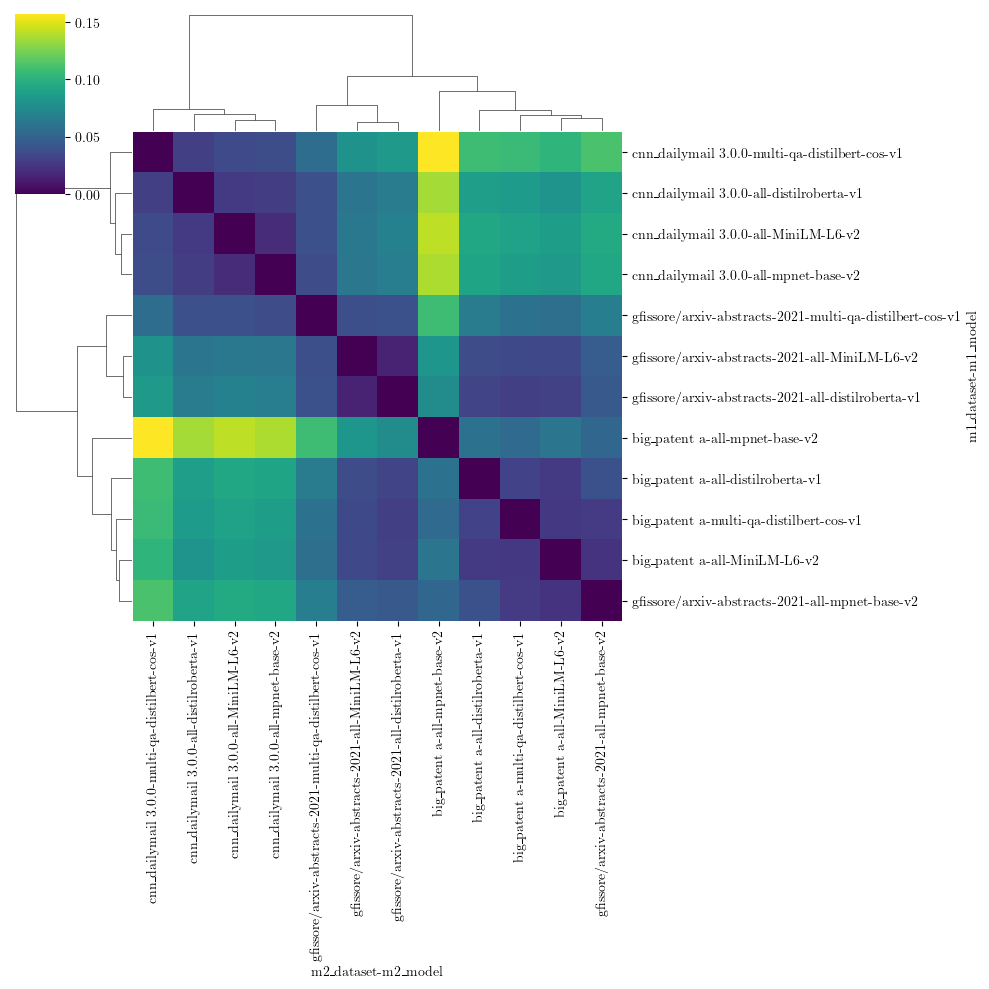

In [399]:
linkage = hc.linkage(sp.distance.squareform(melted_df), method=method, metric=metric)
sns.clustermap(melted_df, row_linkage=linkage, col_linkage=linkage, cmap="viridis")
plt.savefig(f"effects_dataset_model_clustermap_method-{method}_metric-{metric}.pdf", bbox_inches="tight", transparent=True)

In [409]:
from embeddings import clean_dataset_name

In [415]:
method = "ward"
metric = "euclidean"
for idx,dataset in enumerate(datasets):
    melted_small = df_fine.query("m1_n_samples == m2_n_samples == @samples_m2 and m1_n_projections == m2_n_projections == @projections_m2 "
                  + "and m1_dataset == m2_dataset == @dataset"
                 ).pivot(index="m1_model", columns="m2_model", values="aggregate_presto").sort_index().fillna(0)
    melted_small += melted_small.T
    linkage = hc.linkage(sp.distance.squareform(melted_small), method=method, metric=metric)
    sns.clustermap(melted_small, row_linkage=linkage, col_linkage=linkage, cmap="viridis")
    plt.savefig(f"effects_model-only_dataset-{clean_dataset_name(dataset)}_clustermap_method-{method}_metric-{metric}.pdf", bbox_inches="tight", transparent=True)
    plt.close()

In [416]:
method = "ward"
metric = "euclidean"
for idx,model in enumerate(models):
    melted_small = df_fine.query("m1_n_samples == m2_n_samples == @samples_m2 and m1_n_projections == m2_n_projections == @projections_m2 "
                  + "and m1_model == m2_model == @model"
                 ).pivot(index="m1_dataset", columns="m2_dataset", values="aggregate_presto").sort_index().fillna(0)
    melted_small += melted_small.T
    linkage = hc.linkage(sp.distance.squareform(melted_small), method=method, metric=metric)
    sns.clustermap(melted_small, row_linkage=linkage, col_linkage=linkage, cmap="viridis")
    plt.savefig(f"effects_data-only_model-{model}_clustermap_method-{method}_metric-{metric}.pdf", bbox_inches="tight", transparent=True)
    plt.close()

### Model comparisons with varying number of projections (bands are different sample sizes)

In [495]:
df.models.unique()

array(['all-MiniLM-L6-v2/all-distilroberta-v1',
       'all-distilroberta-v1/multi-qa-distilbert-cos-v1',
       'all-mpnet-base-v2/all-MiniLM-L6-v2',
       'all-MiniLM-L6-v2/multi-qa-distilbert-cos-v1',
       'all-mpnet-base-v2/all-distilroberta-v1',
       'all-mpnet-base-v2/multi-qa-distilbert-cos-v1'], dtype=object)

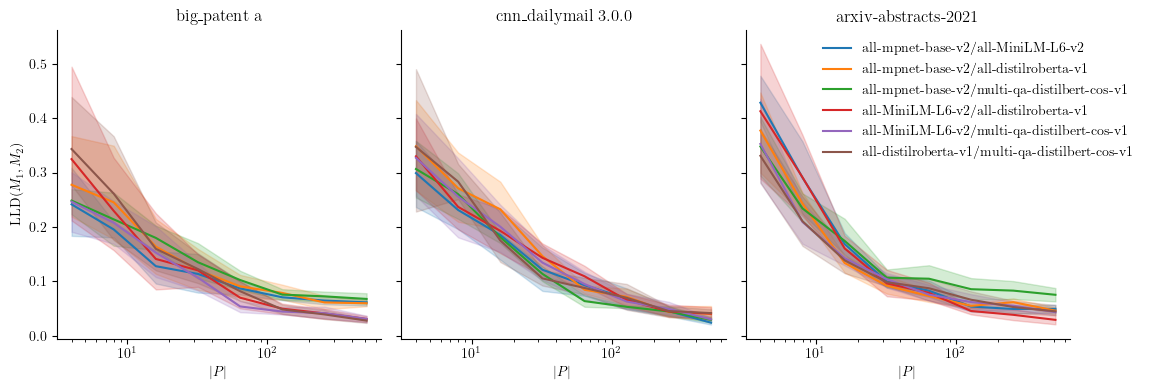

In [498]:
sorted_models = [
       'all-mpnet-base-v2/all-MiniLM-L6-v2',
       'all-mpnet-base-v2/all-distilroberta-v1',
       'all-mpnet-base-v2/multi-qa-distilbert-cos-v1',
        'all-MiniLM-L6-v2/all-distilroberta-v1',
       'all-MiniLM-L6-v2/multi-qa-distilbert-cos-v1',
                'all-distilroberta-v1/multi-qa-distilbert-cos-v1',]
df = df_fine.query("m1_n_samples == m2_n_samples and m1_n_projections == m2_n_projections "
                  + "and m1_dataset == m2_dataset and m1_model != m2_model"
                 )
fig, ax = plt.subplots(1,3,figsize=(12,4), sharex=True, sharey=True)
for idx,dataset in enumerate(sorted(datasets)):
    sns.lineplot(data=df.query("m1_dataset == @dataset").sort_values("models", key=lambda vec:vec.map(lambda x:sorted_models.index(x))), 
                        y="aggregate_presto", x="m1_n_projections", ax=ax[idx], hue="models", legend=False if idx != len(datasets)-1 else True)
    ax[idx].set_title(f"{dataset.split('/')[-1]}")
    ax[idx].set_xscale("log")
    ax[idx].set_xlabel("$|P|$")
ax[0].set_ylabel("LLD$(M_1,M_2)$")
ax[-1].legend(bbox_to_anchor=(0.2,1), frameon=False)
sns.despine(fig)
plt.tight_layout()
plt.savefig(f"effects_n-projections_model-comparisons.pdf", bbox_inches="tight", transparent=True)

### Exploring Landscape Norms

In [549]:
all_norms = dict()
for idx, dataset in enumerate(datasets):
    for idx2,model in enumerate(models):
        for n_samples in config.n_samples:
            landscapes = results[dataset][model][n_samples]["landscapes"]
            landscape_norms_agg = [sum(np.linalg.norm(x) for x in [landscapes[0][idx], landscapes[1][idx], landscapes[2][idx]]) for idx in range(len(landscapes[0]))]
            all_norms[dataset,model,n_samples] = landscape_norms_agg[:]

In [592]:
def get_short_name(dataset):
    if "patent" in dataset:
        return "patent"
    elif "arxiv" in dataset:
        return "arxiv"
    elif "cnn" in dataset:
        return "news"
    else:
        raise NotImplementedError(dataset)

In [593]:
all_norms_df = pd.DataFrame(all_norms)
all_norms_df = pd.DataFrame(all_norms_df.unstack()).reset_index(
).rename({"level_0":"dataset", "level_1":"model", "level_2": "n_samples", "level_3": "projection", 0:"score"}, axis=1)
all_norms_df["config"] = all_norms_df.dataset + "/" + all_norms_df.model
all_norms_df["dataset"] = all_norms_df.dataset.map(lambda dataset:get_short_name(dataset))
all_norms_df.head()

,dataset,model,n_samples,projection,score,config
0,patent,all-mpnet-base-v2,1024,0,0.895625,big_patent a/all-mpnet-base-v2
1,patent,all-mpnet-base-v2,1024,1,0.983234,big_patent a/all-mpnet-base-v2
2,patent,all-mpnet-base-v2,1024,2,1.132316,big_patent a/all-mpnet-base-v2
3,patent,all-mpnet-base-v2,1024,3,1.212579,big_patent a/all-mpnet-base-v2
4,patent,all-mpnet-base-v2,1024,4,0.960146,big_patent a/all-mpnet-base-v2


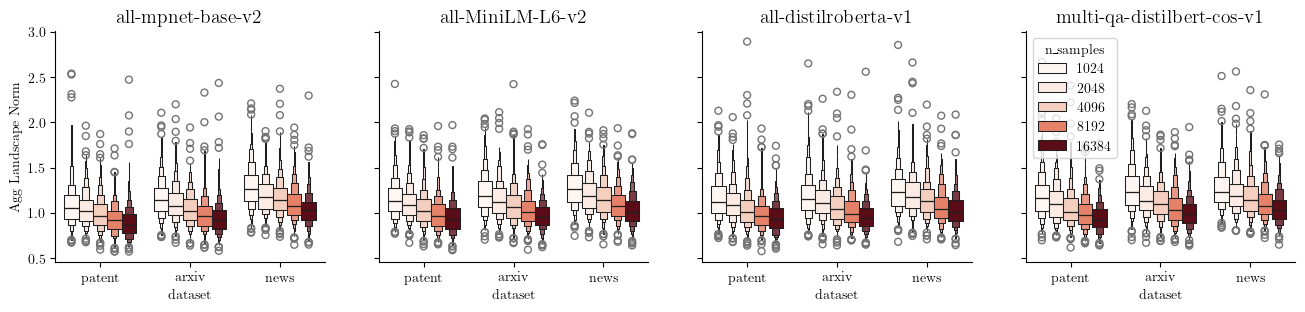

In [597]:
fig, ax = plt.subplots(1,4, figsize=(16,3), sharey=True, sharex=True)
for idx,model in enumerate(models):
    sns.boxenplot(data=all_norms_df.query("model == @model"), x="dataset", y="score", hue="n_samples", ax=ax[idx], palette="Reds", 
                  legend=False if idx != 3 else True)
    ax[idx].set_title(model, fontsize=label_fontsize)
ax[0].set_ylabel("Agg Landscape Norm")
sns.despine(fig)
plt.savefig(f"boxen_landscape-norms.pdf", bbox_inches="tight", transparent=True)

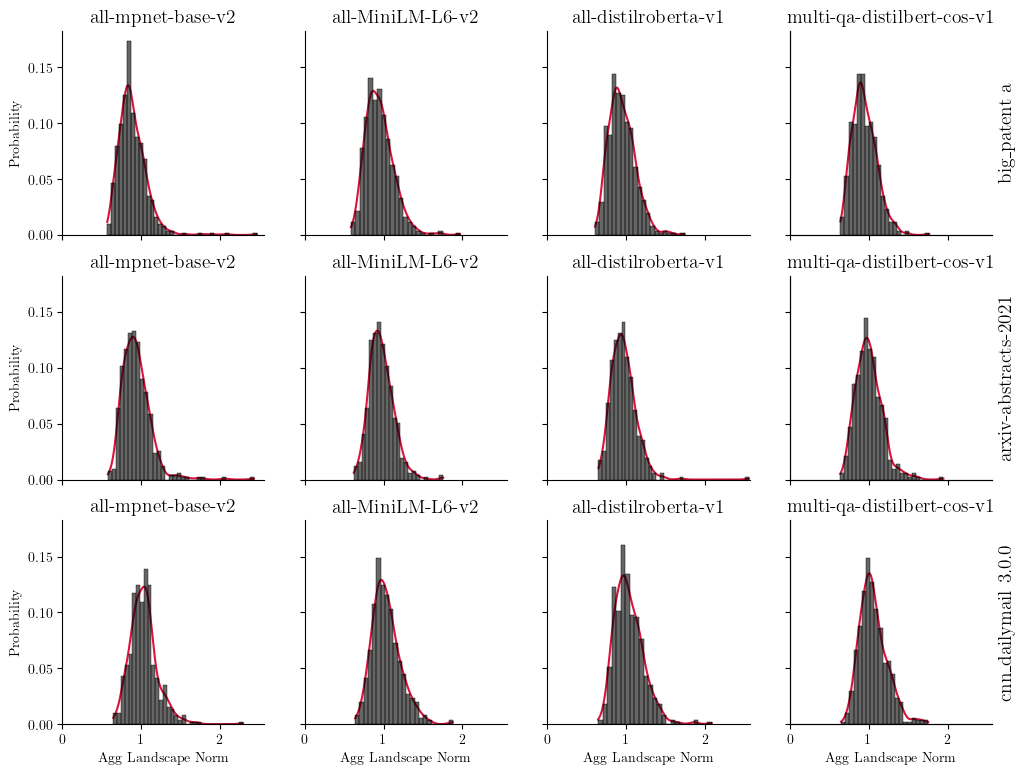

In [548]:
fig, ax = plt.subplots(3,4, figsize=(12,9), sharex=True, sharey=True)
for idx, dataset in enumerate(datasets):
    for idx2,model in enumerate(models):
        landscapes = results[dataset][model][16384]["landscapes"]
        landscape_norms_agg = [sum(np.linalg.norm(x) for x in [landscapes[0][idx], landscapes[1][idx], landscapes[2][idx]]) for idx in range(len(landscapes[0]))]
        sns.histplot(landscape_norms_agg, ax=ax[idx][idx2], stat="probability", kde=True, color="k", alpha=0.6)
        ax[idx][idx2].lines[0].set_color('crimson')
        ax[idx][idx2].lines[0].set_zorder(-1)
        ax[idx][idx2].set_xlim(0,ax[idx][idx2].get_xlim()[-1])
        ax[idx][idx2].set_xlabel("Agg Landscape Norm")
        ax[idx][idx2].set_ylabel("Probability")
        ax[idx][idx2].set_title(f"{model}", fontsize=label_fontsize)
    axx = ax[idx][-1].twinx()
    axx.set_ylabel(dataset.split("/")[-1], fontsize=label_fontsize)
    axx.set_yticks([])
sns.despine(fig)
plt.savefig(f"distributions_landscape-norms.pdf", bbox_inches="tight", transparent=True)

### Below is old

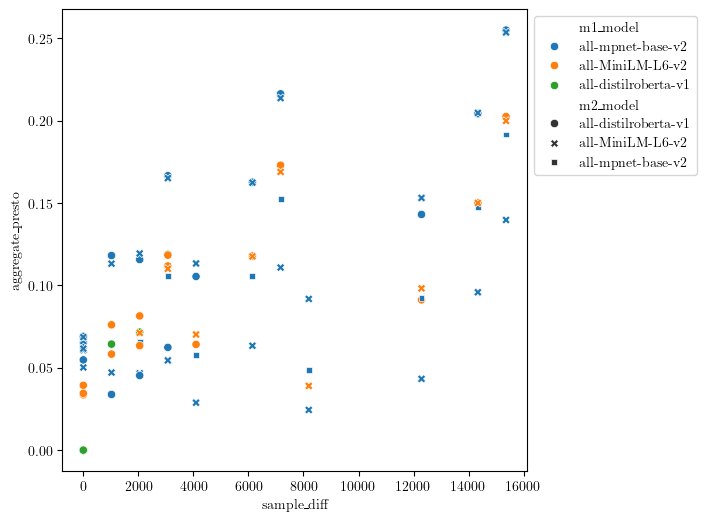

In [119]:
fig, ax = plt.subplots(1,1,figsize=(6,6))
sns.scatterplot(data=df, x="sample_diff", y="aggregate_presto", hue="m1_model", #size="sample_diff", 
                ax=ax, style="m2_model")
plt.legend(bbox_to_anchor=(1,1))
plt.savefig("temp_results.pdf", transparent=True)

### TODO also show dataset differences and compute scores for varying number of projections considered

<Axes: xlabel='sample_diff', ylabel='aggregate_presto'>

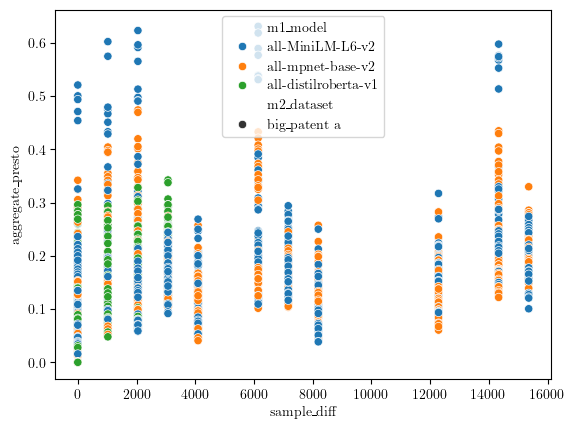

In [133]:
sns.scatterplot(data=df_finegrained.query("m1_model == m2_model"), x="sample_diff", y="aggregate_presto", hue="m1_model", style="m2_dataset")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


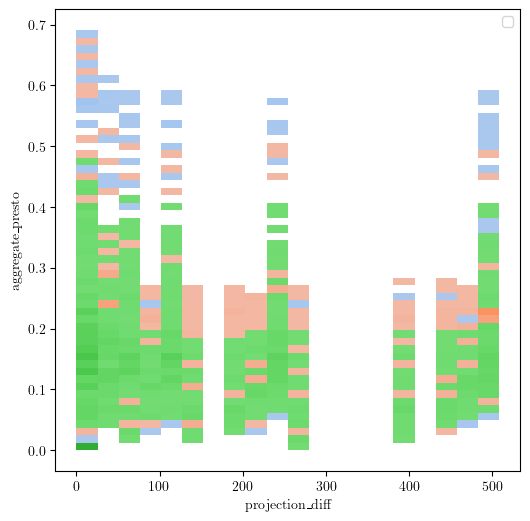

In [126]:
fig, ax = plt.subplots(1,1,figsize=(6,6))
sns.histplot(data=df_finegrained, y="aggregate_presto", x="projection_diff", hue="m2_model", #size="aggregate_presto", 
                ax=ax, #style="m2_model"
            )
plt.legend(bbox_to_anchor=(1,1))
plt.savefig("temp_results_finegrained.pdf", transparent=True)

### Exploring Latent Spaces of Sentence Transformers
Thus far, looking at 
- self-similarity of datasets (noise introduced due to projection), 
- impact of dataset on our assessment,
- impact of n_projections choice on our assessment

Not sure what to make of the results tbh

In [10]:


embeddings = dict()
dataset = config.datasets[0]
n_samples = config.n_samples[0]

for model in models:
    with open(f"embeddings_{re.sub(' ', '___', dataset)}_{n_samples}_{model}.pkl", "rb") as f:
        embeddings[model] = pickle.load(f)

embedding_combinations = list(combinations(embeddings, 2)) + [(e,e) for e in embeddings]

### TODO cleanup
Same dataset, different models, different number of projections (should look at comparisons under PCA w/ different initializations, too)

In [12]:
scores = {c:list() for c in embedding_combinations}
presto_objects = {c:list() for c in embedding_combinations}
for n_projections in config.n_projections[2:3]:
    for e1, e2 in embedding_combinations:
        metric = Presto(max_homology_dim=config.max_homology_dim, n_components=config.n_components, normalize=config.normalize)
        score = metric.fit_transform(embeddings[e1], embeddings[e2], N=n_projections, score_type="aggregate")
        presto_objects[e1,e2].append(metric)
        scores[e1,e2].append(score)
        print(e1, e2, n_projections, score)

all-mpnet-base-v2 all-MiniLM-L6-v2 16 0.16975699624406634
all-mpnet-base-v2 all-distilroberta-v1 16 0.19449708943426838
all-mpnet-base-v2 multi-qa-distilbert-cos-v1 16 0.1447599827309606
all-MiniLM-L6-v2 all-distilroberta-v1 16 0.16415739286879097
all-MiniLM-L6-v2 multi-qa-distilbert-cos-v1 16 0.141268234800346
all-distilroberta-v1 multi-qa-distilbert-cos-v1 16 0.21961972672756228
all-mpnet-base-v2 all-mpnet-base-v2 16 0.1570568112690439
all-MiniLM-L6-v2 all-MiniLM-L6-v2 16 0.18392066687148886
all-distilroberta-v1 all-distilroberta-v1 16 0.2422313146255304
multi-qa-distilbert-cos-v1 multi-qa-distilbert-cos-v1 16 0.15541887386767733


In [24]:
with open(f"presto-objects_cnn_{n_samples}_normalized-{config.normalize}.pkl", "wb") as f:
    pickle.dump(presto_objects, f)
with open(f"scores_cnn_{n_samples}_normalized-{config.normalize}.pkl", "wb") as f:
    pickle.dump(scores, f)

In [26]:
df = pd.DataFrame.from_records(scores)
df["n_projections"] = config.n_projections[:6]
df

,"(all-MiniLM-L6-v2, all-MiniLM-L6-v2)","(all-MiniLM-L6-v2, all-distilroberta-v1)","(all-MiniLM-L6-v2, multi-qa-distilbert-cos-v1)","(all-distilroberta-v1, all-distilroberta-v1)","(all-distilroberta-v1, multi-qa-distilbert-cos-v1)","(all-mpnet-base-v2, all-MiniLM-L6-v2)","(all-mpnet-base-v2, all-distilroberta-v1)","(all-mpnet-base-v2, all-mpnet-base-v2)","(all-mpnet-base-v2, multi-qa-distilbert-cos-v1)","(multi-qa-distilbert-cos-v1, multi-qa-distilbert-cos-v1)",n_projections
0,0.295682,0.272834,0.242314,0.281481,0.648453,0.225095,0.358418,0.316168,0.416772,0.224383,4
1,0.167994,0.151546,0.349840,0.310389,0.300237,0.174486,0.299249,0.374607,0.231556,0.241933,8
2,0.277847,0.141369,0.120354,0.274087,0.216557,0.279866,0.152738,0.264671,0.168364,0.237447,16
3,0.205368,0.129020,0.151125,0.205366,0.120048,0.152587,0.090784,0.072832,0.162585,0.118735,32
4,0.134400,0.075782,0.098200,0.076133,0.148071,0.047589,0.095023,0.085921,0.137962,0.055034,64
5,0.046003,0.068635,0.094029,0.107640,0.059286,0.094387,0.110778,0.068069,0.079345,0.106406,128


In [27]:
melted_df = df.melt(id_vars=["n_projections"])
melted_df.head()

,n_projections,variable,value
0,4,"(all-MiniLM-L6-v2, all-MiniLM-L6-v2)",0.295682
1,8,"(all-MiniLM-L6-v2, all-MiniLM-L6-v2)",0.167994
2,16,"(all-MiniLM-L6-v2, all-MiniLM-L6-v2)",0.277847
3,32,"(all-MiniLM-L6-v2, all-MiniLM-L6-v2)",0.205368
4,64,"(all-MiniLM-L6-v2, all-MiniLM-L6-v2)",0.134400


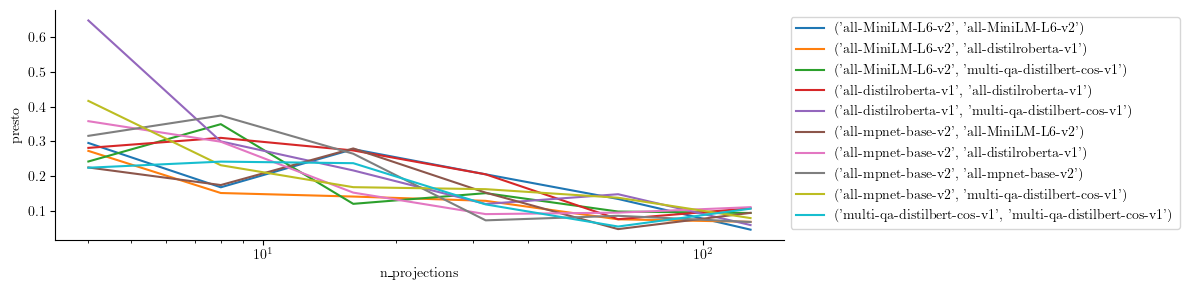

In [29]:
fig, ax = plt.subplots(1,1,figsize=(12,3))
sns.lineplot(melted_df, x="n_projections", y="value", hue="variable")
sns.despine(fig)
ax.set_xscale("log")
ax.set_ylabel("presto")
plt.legend(bbox_to_anchor=(1,1))
plt.tight_layout()
plt.savefig(f"presto_cnn_{n_samples}_scores.pdf", bbox_inches="tight", transparent=True)